In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/7
    print("準備完了！このまま下のセルを実行できます。")

# 第7章 勾配降下法 (Gradient Descent)
## 7.3 収束性 (Convergence)

### 本節の概要と位置づけ
前節（7.2節）では、バッチ勾配降下法、確率的勾配降下法（SGD, アルゴリズム 7.1）、ミニバッチ法（アルゴリズム 7.2）、およびHe初期化の統計的基礎を学びました。

勾配降下法を実際の深層ネットワークに適用する際、学習率 $\eta$ の適切な選定と**収束速度（Convergence Rate）**の制御が最大の工学的・数理的課題となります。
重み空間において誤差曲面の曲率が方向によって大きく異なる場合、誤差曲面は**「細長い谷（Long Valley）」**の形状を呈します（Figure 7.3）。このような谷において、局所勾配ベクトル $-\nabla E$ は最小値の方向を向かず、谷の幅方向（高曲率方向）に激しく振動しながら、谷の底に沿った進行方向（低曲率方向）への前進が極めて遅くなってしまいます。

本節（7.3節）では、局所2次近似に基づく収束の厳密な固有値解析から出発し、現代の深層学習で不可欠な以下の加速技術・適応的最適化手法を体系的に探求します：
1. **2次近似における収束解析**:
   - 固有座標系における独立な距離減衰 $\alpha_i^{(\tau)} = (1 - \eta \lambda_i)^\tau \alpha_i^{(0)}$ (Eq 7.29)。
   - 発散を防止する最大安定学習率 $\eta < \frac{2}{\lambda_{\max}}$。
   - 条件数 $\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$ と最遅方向の収束係数 $1 - \frac{2}{\kappa}$ (Eq 7.30)。
   - **Figure 7.3**: 細長い谷における固定ステップ勾配降下法の横断振動。
2. **モーメンタム法 (7.3.1項)**:
   - 慣性項の導入 $\Delta \mathbf{w}^{(\tau-1)} = -\eta \nabla E + \mu \Delta \mathbf{w}^{(\tau-2)}$ (Eq 7.31)。
   - 低曲率領域における実効学習率の増大 $\frac{\eta}{1 - \mu}$ (**Figure 7.4**, Eq 7.33)。
   - 高曲率領域における振動相殺効果 (**Figure 7.5**)。
   - **Figure 7.6**: モーメンタム法による谷に沿った劇的な加速。
   - **アルゴリズム 7.3**: モーメンタム付き確率的勾配降下法。
   - **Nesterovモーメンタム** (Eq 7.34) の先読み勾配計算。
3. **学習率スケジューリング (7.3.2項)**:
   - 時間変化する学習率 $\eta^{(\tau)}$ (Eq 7.35)。
   - 線形減衰 (Eq 7.36)、べき乗減衰 (Eq 7.37)、指数減衰 (Eq 7.38)。
4. **RMSProp と Adam (7.3.3項)**:
   - AdaGrad (Eq 7.39, 7.40) の累積二乗勾配による自動減衰。
   - RMSProp (Eq 7.41, 7.42) の指数移動平均による学習率自動調整。
   - **Adam (アルゴリズム 7.4)**: 1次モーメント（モーメンタム）と2次モーメント（RMSProp）の融合、およびゼロ初期化バイアス補正 (Eq 7.43–7.47)。


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if os.path.basename(current_dir) == "7" else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.convergence import (
    max_stable_learning_rate,
    condition_number,
    convergence_rate_dominant_axis,
    eigen_distance_evolution,
    effective_momentum_learning_rate,
    gradient_descent_momentum,
    sgd_momentum_algorithm_7_3,
    LinearLRScheduler,
    PowerLawLRScheduler,
    ExponentialLRScheduler,
    adagrad_optimizer,
    rmsprop_optimizer,
    adam_optimizer,
    generate_figure_7_3,
    generate_figure_7_4,
    generate_figure_7_5,
    generate_figure_7_6,
)
from common.plot_utils import setup_style

setup_style()
print("All convergence modules imported successfully.")


All convergence modules imported successfully.


---

## 局所2次近似における収束性解析 (Convergence Analysis)

最小値 $\mathbf{w}^\star$ の近傍において、誤差関数の2次近似（7.7式）を考えます。ヘッセ行列 $\mathbf{H}$ の固有方程式 $\mathbf{H}\mathbf{u}_i = \lambda_i \mathbf{u}_i$（7.8式）および正規直交性 $\mathbf{u}_i^T \mathbf{u}_j = \delta_{ij}$（7.9式）を用いると、勾配ベクトルは次のように展開されます：
$$
\nabla E(\mathbf{w}) = \sum_i \alpha_i \lambda_i \mathbf{u}_i \tag{7.24}
$$
ここで $\alpha_i = \mathbf{u}_i^T (\mathbf{w} - \mathbf{w}^\star)$（7.28式）は、最小値から測った固有ベクトル $\mathbf{u}_i$ 方向の距離成分です。

重み変化量 $\Delta \mathbf{w} = \sum_i \Delta \alpha_i \mathbf{u}_i$（7.25式）と勾配降下更新則 $\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta \nabla E(\mathbf{w}^{(\tau-1)})$ を組み合わせると、各ステップにおける各軸成分の変化量は互いに完全に分離（Decoupled）されます：
$$
\Delta \alpha_i = -\eta \lambda_i \alpha_i \tag{7.26}
$$
したがって、1ステップ後の距離成分は直前の値に定数倍される漸化式に従います（演習問題 7.10）：
$$
\alpha_i^{\text{new}} = (1 - \eta \lambda_i) \alpha_i^{\text{old}} \tag{7.27}
$$
$T$ 回の更新ステップを経た後の距離は：
$$
\alpha_i^{(T)} = (1 - \eta \lambda_i)^T \alpha_i^{(0)} \tag{7.29}
$$
となります。

### 線形収束条件と最大安定学習率
$T \to \infty$ において $\mathbf{w} \to \mathbf{w}^\star$（すなわち全成分 $\alpha_i^{(T)} \to 0$）へ収束するための必要十分条件は、すべての固有値に対して以下が成り立つことです：
$$
|1 - \eta \lambda_i| < 1 \iff 0 < \eta < \frac{2}{\lambda_{\max}}
$$
ここで $\lambda_{\max}$ はヘッセ行列の最大固有値です。

### 最遅方向の収束速度とヘッセ行列の条件数
学習率 $\eta$ を発散限界の最大値 $\eta = \frac{2}{\lambda_{\max}}$ に設定したとき、最小固有値 $\lambda_{\min}$（Figure 7.3における楕円の長軸方向）に沿った収束率は次式で支配されます：
$$
\left| 1 - \frac{2\lambda_{\min}}{\lambda_{\max}} \right| = 1 - \frac{2}{\kappa} \tag{7.30}
$$
ここで $\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$ はヘッセ行列の**条件数（Condition Number）**です。
条件数 $\kappa$ が極めて大きい（$\kappa \gg 1$）場合、収束係数は $1$ に極めて近くなり、最小値への前進は極度に遅滞します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_3_valley_oscillation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_3_valley_oscillation.png
Figure 7.3 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_3_valley_oscillation.png


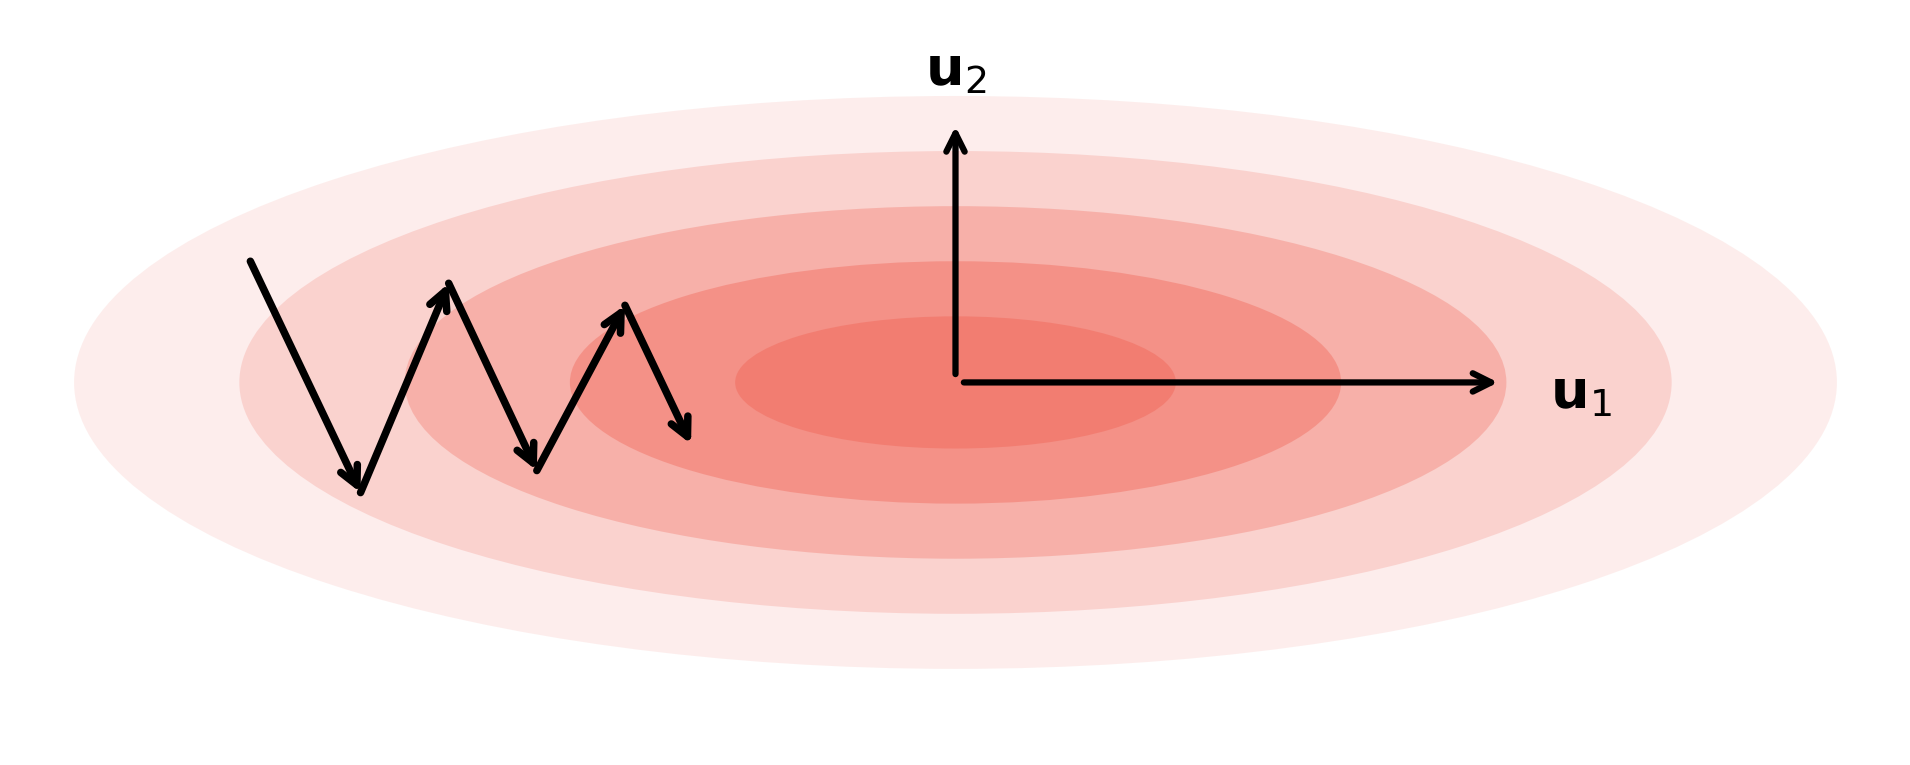

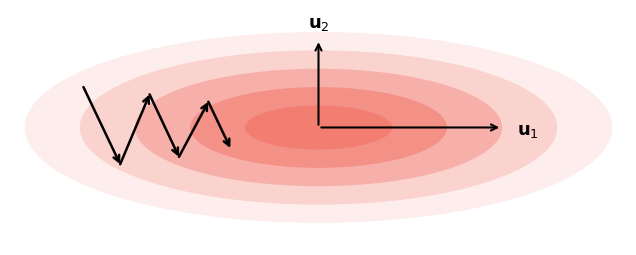

In [2]:
# Figure 7.3 の再現: 細長い谷における固定ステップ勾配降下法の横断振動
fig_7_3_path, _ = generate_figure_7_3()
print(f"Figure 7.3 saved to: {fig_7_3_path}")

# インライン表示
from IPython.display import Image, display
display(Image(filename=fig_7_3_path))


---

## 7.3.1 モーメンタム法 (Momentum)

固有値の比（条件数 $\kappa$）が極めて大きい問題に対処する簡明で強力な手法が、勾配降下法に**モーメンタム項（慣性項）**を付加することです（Eq 7.31）：
$$
\Delta \mathbf{w}^{(\tau-1)} = -\eta \nabla E(\mathbf{w}^{(\tau-1)}) + \mu \Delta \mathbf{w}^{(\tau-2)} \tag{7.31}
$$
ここで $\mu$ はモーメンタムパラメータであり、通常 $0 \le \mu < 1$（実務上は $\mu = 0.9$ が多用される）に設定されます。重みベクトルは $\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} + \Delta \mathbf{w}^{(\tau-1)}$ により更新されます。

### モーメンタムのメカニズム
1. **低曲率領域（平坦な谷底）における実効学習率の増大 (Figure 7.4)**:
   勾配がおよそ一定である領域では、過去の更新量が公比 $\mu$ の等比級数として累積されます：
   $$
   \Delta \mathbf{w} = -\eta \nabla E \{ 1 + \mu + \mu^2 + \dots \} = -\frac{\eta}{1 - \mu} \nabla E \tag{7.32, 7.33}
   $$
   したがって、モーメンタム項は実効的な学習率を $\eta$ から **$\frac{\eta}{1 - \mu}$**（例えば $\mu = 0.9$ のとき **$10\eta$**）へと大幅に引き上げ、進行を加速します。

2. **高曲率領域における振動の相殺 (Figure 7.5)**:
   谷を挟んで勾配の符号がステップごとに反転する高曲率方向では、連続する更新量の符号が逆となるため、モーメンタム項が互いに打ち消し合います。その結果、実効学習率は $\eta$ の近傍にとどまり、発散振動を引き起こすことなく安定性を維持します。

3. **谷に沿った加速 (Figure 7.6)**:
   この2つの効果が同時に作用することにより、高曲率方向の振動を抑え込みつつ、低曲率の谷底方向へと迅速に加速して最小値へ到達します。

```
=============================================================================
アルゴリズム 7.3: モーメンタム付き確率的勾配降下法
=============================================================================
入力: データ点インデックス n in {1, ..., N} で表される訓練データセット
      バッチサイズ B
      ミニバッチごとの誤差関数 E_{n:n+B-1}(w)
      学習率パラメータ eta
      モーメンタムパラメータ mu
      初期重みベクトル w
出力: 最終重みベクトル w

n <- 1
Delta w <- 0
repeat
    Delta w <- -eta * grad E_{n:n+B-1}(w) + mu * Delta w   // 更新項の計算
    w <- w + Delta w                                       // 重みベクトルの更新
    n <- n + B
    if n > N then
        データをシャッフル
        n <- 1
    end if
until 収束
return w
=============================================================================
```

### Nesterov モーメンタム (NAG)
収束をさらに加速する手法として **Nesterovモーメンタム (Nesterov Accelerated Gradient)** が知られています：
$$
\Delta \mathbf{w}^{(\tau-1)} = -\eta \nabla E(\mathbf{w}^{(\tau-1)} + \mu \Delta \mathbf{w}^{(\tau-2)}) + \mu \Delta \mathbf{w}^{(\tau-2)} \tag{7.34}
$$
通常のモーメンタム法では現在位置で勾配を計算した後に慣性を加えますが、Nesterov法では「慣性によって先に進んだ将来の予測位置」において勾配を評価し、急ブレーキや軌道修正を事前に適用します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_4_linear_convergence.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_4_linear_convergence.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_5_oscillatory_cancellation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_5_oscillatory_cancellation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_6_momentum_acceleration.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_6_momentum_acceleration.png
Figure 7.4 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_4_linear_convergence.png
Figure 7.5 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_5_oscillatory_cancellation.png
Figure 7.6 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_6_momentum_acceleration.png


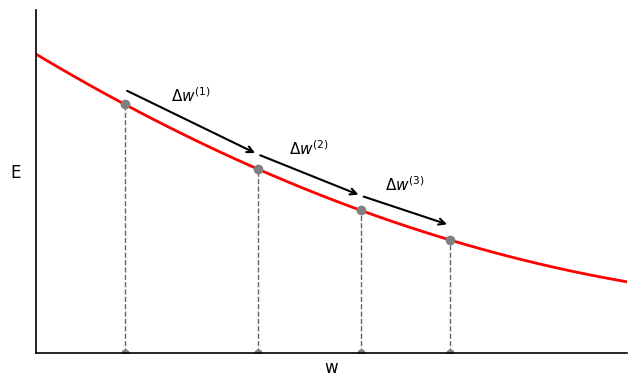

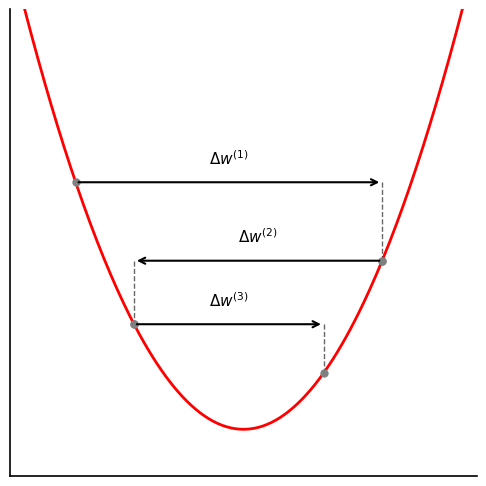

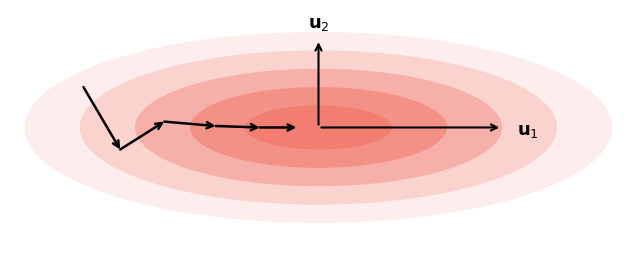

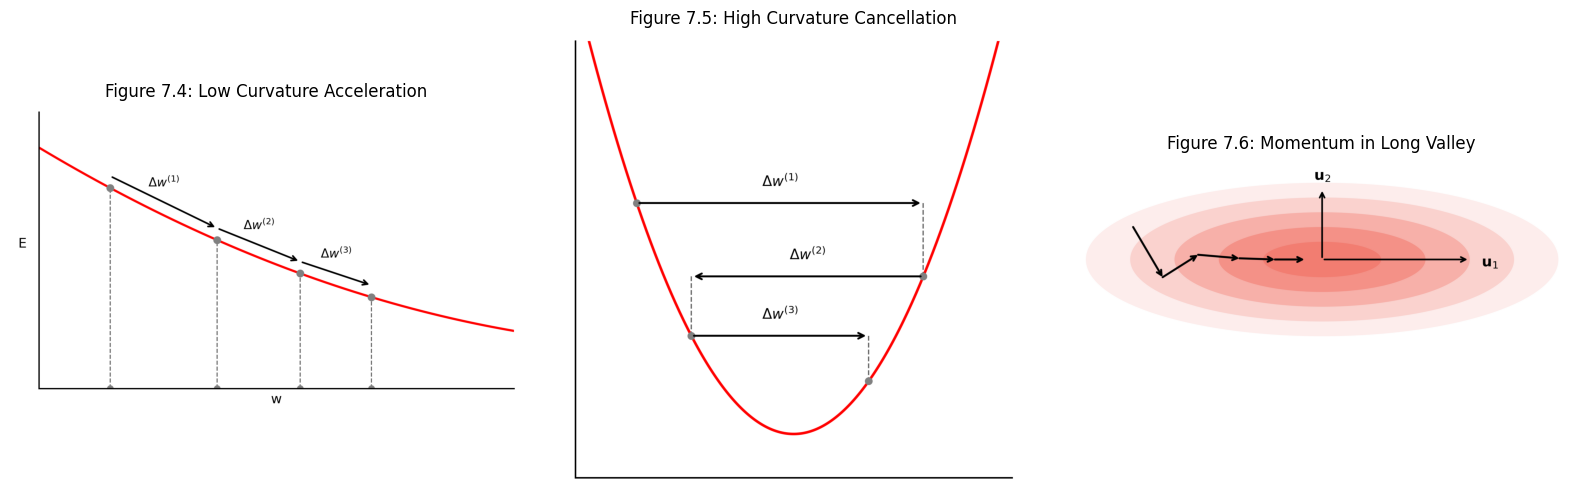

In [3]:
# Figure 7.4, 7.5, 7.6 の再現
fig_7_4_path, _ = generate_figure_7_4()
fig_7_5_path, _ = generate_figure_7_5()
fig_7_6_path, _ = generate_figure_7_6()

print(f"Figure 7.4 saved to: {fig_7_4_path}")
print(f"Figure 7.5 saved to: {fig_7_5_path}")
print(f"Figure 7.6 saved to: {fig_7_6_path}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im4 = plt.imread(fig_7_4_path)
im5 = plt.imread(fig_7_5_path)
im6 = plt.imread(fig_7_6_path)

axes[0].imshow(im4)
axes[0].set_title("Figure 7.4: Low Curvature Acceleration", fontsize=12)
axes[0].axis("off")

axes[1].imshow(im5)
axes[1].set_title("Figure 7.5: High Curvature Cancellation", fontsize=12)
axes[1].axis("off")

axes[2].imshow(im6)
axes[2].set_title("Figure 7.6: Momentum in Long Valley", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()


---

## 7.3.2 学習率スケジュール (Learning Rate Schedule)

固定の学習率 $\eta$ を用いる代わりに、訓練の進行（反復ステップ $\tau$）に応じて学習率を動的に減衰させる手法です：
$$
\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta^{(\tau-1)} \nabla E_n(\mathbf{w}^{(\tau-1)}) \tag{7.35}
$$
初期段階では大きな学習率で重み空間を大局的に探索し、最適解の近傍に近づくにつれて小さな学習率へ移行することで、SGD特有の確率的振動を抑えて精密に収束させます。

主要なスケジュール形式：
1. **線形減衰 (Linear Decay)** (Eq 7.36):
   $$
   \eta^{(\tau)} = \left( 1 - \frac{\tau}{K} \right) \eta^{(0)} + \left( \frac{\tau}{K} \right) \eta^{(K)}
   $$
   ステップ数 $K$ にわたって初期値 $\eta^{(0)}$ から $\eta^{(K)}$ へと線形に減少し、以降は $\eta^{(K)}$ に固定されます。
2. **べき乗減衰 (Power-law Decay)** (Eq 7.37):
   $$
   \eta^{(\tau)} = \frac{\eta^{(0)}}{(1 + \tau / s)^c}
   $$
3. **指数減衰 (Exponential Decay)** (Eq 7.38):
   $$
   \eta^{(\tau)} = \eta^{(0)} c^{\tau / s} \quad (0 < c < 1)
   $$


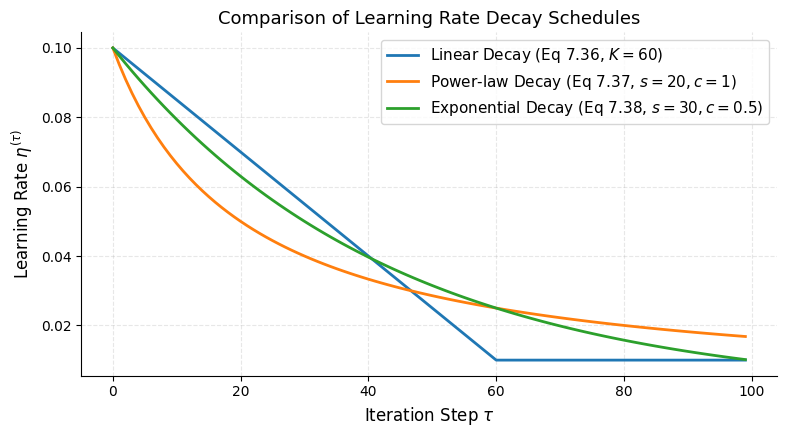

In [4]:
# 7.3.2項: 各種学習率スケジュールの軌跡比較
tau_steps = np.arange(0, 100)

sched_linear = LinearLRScheduler(eta_0=0.1, eta_K=0.01, K=60)
sched_power = PowerLawLRScheduler(eta_0=0.1, s=20.0, c=1.0)
sched_exp = ExponentialLRScheduler(eta_0=0.1, s=30.0, c=0.5)

lr_linear = [sched_linear(t) for t in tau_steps]
lr_power = [sched_power(t) for t in tau_steps]
lr_exp = [sched_exp(t) for t in tau_steps]

plt.figure(figsize=(8, 4.5))
plt.plot(tau_steps, lr_linear, label=r"Linear Decay (Eq 7.36, $K=60$)", lw=2)
plt.plot(tau_steps, lr_power, label=r"Power-law Decay (Eq 7.37, $s=20, c=1$)", lw=2)
plt.plot(tau_steps, lr_exp, label=r"Exponential Decay (Eq 7.38, $s=30, c=0.5$)", lw=2)
plt.xlabel(r"Iteration Step $\tau$", fontsize=12)
plt.ylabel(r"Learning Rate $\eta^{(\tau)}$", fontsize=12)
plt.title("Comparison of Learning Rate Decay Schedules", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---

## 7.3.3 RMSProp と Adam (RMSProp and Adam)

誤差曲面の局所曲率はパラメータ空間の軸ごとに異なるため、各パラメータ（重み $w_i$）ごとに個別の学習率を割り当て、訓練中に自動調整する**適応的学習率最適化器（Adaptive Learning Rate Optimizers）**が開発されました。

### 1. AdaGrad (Duchi et al., 2011)
過去に計算された全勾配の二乗和 $r_i$ を蓄積し、勾配の二乗和が大きい（曲率の高い）パラメータの学習率を急速に減少させます：
$$
r_i^{(\tau)} = r_i^{(\tau-1)} + \left( \frac{\partial E}{\partial w_i} \right)^2 \tag{7.39}
$$
$$
w_i^{(\tau)} = w_i^{(\tau-1)} - \frac{\eta}{\sqrt{r_i^{(\tau)} + \delta}} \frac{\partial E}{\partial w_i} \tag{7.40}
$$
ここで $\delta$（通常 $10^{-8}$）はゼロ除算を防ぐ微小定数です。
**欠点**: 二乗勾配が訓練開始時から単調に累積され続けるため、後半で実効学習率が過度に消失し、学習が停止してしまいます。

### 2. RMSProp (Hinton, 2012)
AdaGradの欠点を克服するため、二乗勾配の累積を**指数移動平均（EMA）**に置き換えます：
$$
r_i^{(\tau)} = \beta r_i^{(\tau-1)} + (1 - \beta) \left( \frac{\partial E}{\partial w_i} \right)^2 \tag{7.41}
$$
$$
w_i^{(\tau)} = w_i^{(\tau-1)} - \frac{\eta}{\sqrt{r_i^{(\tau)} + \delta}} \frac{\partial E}{\partial w_i} \tag{7.42}
$$
減衰係数 $\beta \in (0, 1)$（典型値は $\beta = 0.9$）により過去の古い勾配情報を忘れ、直近の局所曲率にのみ適応します。

### 3. Adam (Kingma and Ba, 2014)
RMSPropにモーメンタム（1次モーメント）を統合した、現代の深層学習で最も広く使われる最適化器です：
- **1次モーメント（勾配の指数移動平均）**:
  $$
  s_i^{(\tau)} = \beta_1 s_i^{(\tau-1)} + (1 - \beta_1) \frac{\partial E}{\partial w_i} \tag{7.43}
  $$
- **2次モーメント（二乗勾配の指数移動平均）**:
  $$
  r_i^{(\tau)} = \beta_2 r_i^{(\tau-1)} + (1 - \beta_2) \left( \frac{\partial E}{\partial w_i} \right)^2 \tag{7.44}
  $$
- **ゼロ初期化バイアス補正 (Bias Correction)**:
  初期値 $s_i^{(0)} = 0, r_i^{(0)} = 0$ に起因する初期ステップでの過小評価バイアスを補正します（演習問題 7.12）：
  $$
  \widehat{s}_i^{(\tau)} = \frac{s_i^{(\tau)}}{1 - \beta_1^\tau} \tag{7.45}, \quad \widehat{r}_i^{(\tau)} = \frac{r_i^{(\tau)}}{1 - \beta_2^\tau} \tag{7.46}
  $$
- **パラメータ更新**:
  $$
  w_i^{(\tau)} = w_i^{(\tau-1)} - \eta \frac{\widehat{s}_i^{(\tau)}}{\sqrt{\widehat{r}_i^{(\tau)}} + \delta} \tag{7.47}
  $$
標準的なハイパーパラメータ値は $\beta_1 = 0.9, \beta_2 = 0.999, \delta = 10^{-8}$ です。

```
=============================================================================
アルゴリズム 7.4: Adam 最適化 (Adam optimization)
=============================================================================
入力: データ点インデックス n in {1, ..., N} で表される訓練データセット
      バッチサイズ B
      ミニバッチごとの誤差関数 E_{n:n+B-1}(w)
      学習率パラメータ eta
      減衰パラメータ beta1, beta2
      安定化パラメータ delta
出力: 最終重みベクトル w

n <- 1
s <- 0
r <- 0
repeat
    訓練セット D からランダムにミニバッチを選択
    g = -grad E_{n:n+B-1}(w)      // 勾配ベクトルの評価
    s <- beta1 * s + (1 - beta1) * g
    r <- beta2 * r + (1 - beta2) * (g * g)   // 要素ごとの積
    s_hat <- s / (1 - beta1^tau)             // バイアス補正
    r_hat <- r / (1 - beta2^tau)             // バイアス補正
    Delta w <- -eta * s_hat / (sqrt(r_hat) + delta)
    w <- w + Delta w                         // 重みベクトルの更新
    n <- n + B
    if n + B > N then
        データをシャッフル
        n <- 1
    end if
until 収束
return w
=============================================================================
```


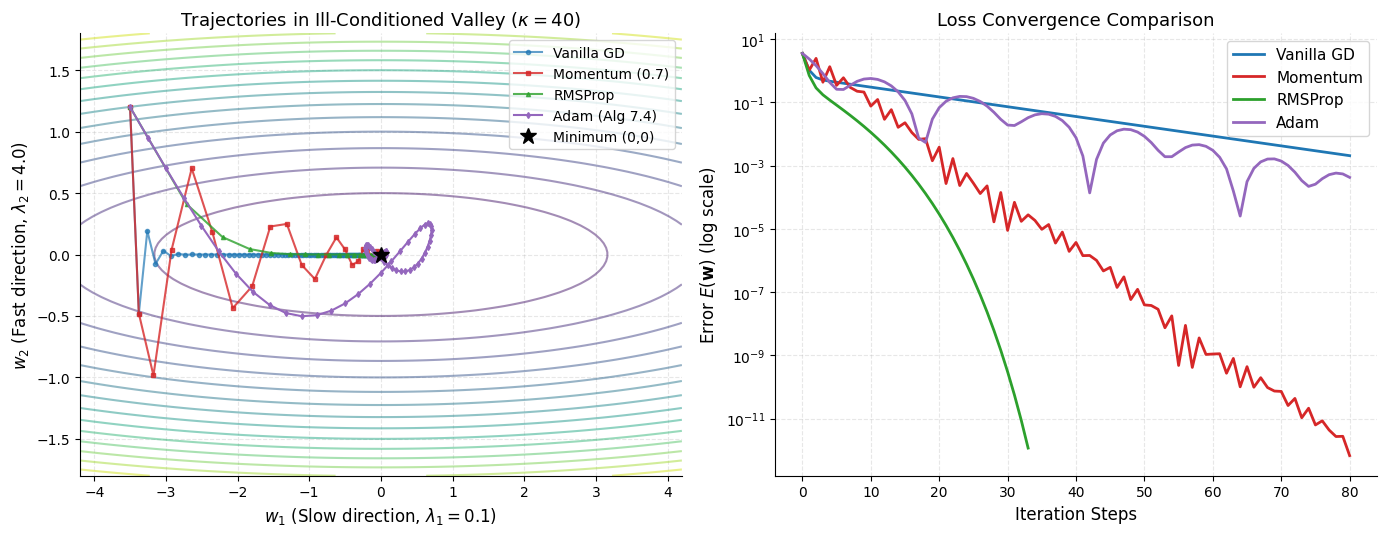

In [5]:
# 7.3.3項: 各種最適化手法（GD, Momentum, RMSProp, Adam）の比較実験
# 条件数の高い異方的2次曲面における挙動比較
A_mat = np.array([[0.1, 0.0], [0.0, 4.0]])  # 条件数 kappa = 40
w_target = np.array([0.0, 0.0])
w_start = np.array([-3.5, 1.2])

def quad_loss(w):
    return 0.5 * float(w.T @ A_mat @ w)

def quad_grad(w):
    return A_mat @ w

steps_run = 80

# 1. Vanilla GD (lr = 0.4: y軸方向の発散限界 2/4.0 = 0.5 の直下)
res_gd = gradient_descent_momentum(w_start, quad_grad, error_fn=quad_loss, lr=0.35, momentum=0.0, max_steps=steps_run)
# 2. Momentum (lr = 0.35, mu = 0.7)
res_mom = gradient_descent_momentum(w_start, quad_grad, error_fn=quad_loss, lr=0.35, momentum=0.7, max_steps=steps_run)
# 3. RMSProp (lr = 0.25, beta = 0.9)
res_rms = rmsprop_optimizer(w_start, quad_grad, error_fn=quad_loss, lr=0.25, beta=0.9, max_steps=steps_run)
# 4. Adam (lr = 0.25, beta1 = 0.9, beta2 = 0.999)
res_adam = adam_optimizer(w_start, quad_grad, error_fn=quad_loss, lr=0.25, beta1=0.9, beta2=0.999, max_steps=steps_run)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 等高線と軌道
w1_vals = np.linspace(-4.2, 4.2, 100)
w2_vals = np.linspace(-1.8, 1.8, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Loss_grid = 0.5 * (0.1 * W1**2 + 4.0 * W2**2)

ax1.contour(W1, W2, Loss_grid, levels=15, cmap="viridis", alpha=0.5)
ax1.plot(res_gd.weights[:, 0], res_gd.weights[:, 1], "o-", color="#1f77b4", label="Vanilla GD", markersize=3, alpha=0.7)
ax1.plot(res_mom.weights[:, 0], res_mom.weights[:, 1], "s-", color="#d62728", label="Momentum (0.7)", markersize=3, alpha=0.8)
ax1.plot(res_rms.weights[:, 0], res_rms.weights[:, 1], "^-", color="#2ca02c", label="RMSProp", markersize=3, alpha=0.8)
ax1.plot(res_adam.weights[:, 0], res_adam.weights[:, 1], "d-", color="#9467bd", label="Adam (Alg 7.4)", markersize=3)
ax1.plot(0, 0, "k*", markersize=12, label="Minimum (0,0)")
ax1.set_xlabel("$w_1$ (Slow direction, $\lambda_1 = 0.1$)", fontsize=12)
ax1.set_ylabel("$w_2$ (Fast direction, $\lambda_2 = 4.0$)", fontsize=12)
ax1.set_title("Trajectories in Ill-Conditioned Valley ($\kappa = 40$)", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 誤差収束曲線
ax2.plot(res_gd.errors, label="Vanilla GD", color="#1f77b4", lw=2)
ax2.plot(res_mom.errors, label="Momentum", color="#d62728", lw=2)
ax2.plot(res_rms.errors, label="RMSProp", color="#2ca02c", lw=2)
ax2.plot(res_adam.errors, label="Adam", color="#9467bd", lw=2)
ax2.set_xlabel("Iteration Steps", fontsize=12)
ax2.set_ylabel(r"Error $E(\mathbf{w})$ (log scale)", fontsize=12)
ax2.set_yscale("log")
ax2.set_title("Loss Convergence Comparison", fontsize=13)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


---

## 7.3節のまとめと次節（7.4節 正規化）への展望

本節（7.3節）では、勾配降下法の収束性数理と現代的な加速・適応手法を体系的に網羅しました：
1. **異方的曲率と条件数**: ヘッセ行列の固有値差（条件数 $\kappa = \lambda_{\max}/\lambda_{\min}$）が大きい場合、固定ステップ勾配降下法は谷を横切る振動に陥り、最遅方向の収束は $1 - 2/\kappa$ に制限される（**Figure 7.3**, Eq 7.30）。
2. **モーメンタムの二重効果**:
   - 低曲率領域では等比級数的累積により実効学習率を $\eta / (1 - \mu)$ へ増大（**Figure 7.4**）。
   - 高曲率領域では反転する更新量が相殺して安定性を維持（**Figure 7.5**）。
   - 結果として谷に沿った劇的な高速進行を実現（**Figure 7.6**, **アルゴリズム 7.3**）。
3. **適応的学習率最適化器**:
   - RMSProp は二乗勾配の指数移動平均により各軸の局所スケールに適応。
   - **Adam (アルゴリズム 7.4)** は1次モーメントと2次モーメントを統合し、バイアス補正を備えた深層学習の業界標準手法。

### 次節（7.4節 正規化）への接続
本節で見た通り、最適化の最大の障害は入力特徴量や中間層ユニットの間でスケールや曲率が著しく異なること（病的な楕円等高線）に起因します。
次節（7.4節）では、入力特徴量の正規化、ミニバッチごとの**バッチ正規化 (Batch Normalization)**、および隠れユニット次元方向の**層正規化 (Layer Normalization)** の数理を学び、誤差曲面そのものを球状（等方的）に整形して収束を飛躍的に加速する技術を修得します。
